# Step 8: Manuscript Figures

Russell Blessing

## Overview

This notebook builds the manuscript figures from the finalized outputs of the earlier pipeline steps. The first deliverable is **Fig. 2** — the *flooded-to-funded* pipeline funnel.

The pipeline tracks residential properties through five sequential, nested stages:

| \# | Stage | Definition | Source |
|--------|-----------------|----------------------------|-------------------|
| 1 | **flooded** | intersected the footprint of ≥ 1 of the 78 modelled events | Step 7 |
| 2 | **eligible** | flooded during an event for which its county received a PDD | Step 7 |
| 3 | **in a community** | its community (city, else county) is one where the local government assisted with the submission of ≥ 1 HMA application | Step 5 `apps_pcls` |
| 4 | **applied** | the property itself is named on an HMA application | Step 5 `apps_pcls` |
| 5 | **funded** | the property received a mitigation | Step 5 `mits_pcls` |

The funnel is computed twice: once for **all** flood-exposed residential properties, and once for the subset exposed to flooding **more than once**.

In [ ]:
library(sf)

Linking to GEOS 3.12.0, GDAL 3.11.0, PROJ 9.2.1; sf_use_s2() is TRUE


Attaching package: 'dplyr'

The following objects are masked from 'package:stats':

    filter, lag

The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union

here() starts at /proj/mhinolab/users/rbless/Obstacles

------------------------------------------------------------------------

## 1 Configuration

In [ ]:
out_dir <- "/proj/mhinolab/users/rbless/data/Obstacles_Output"

cfg <- list(
  master_path      = file.path(out_dir, "parcels_master.gpkg"),
  repeat_threshold = 2L
)

------------------------------------------------------------------------

## 2 Diagnostic — what is actually in the files

In [ ]:
needed <- c("parcel_index", "cntyfips", "SITUS.CITY",
            "flooded_any", "eligible", "fr_1_4", "interpolate",
            "value", "cent_lat", "cent_lng", "eif_lat", "eif_lon",
            "applied", "funded", "pct_white_2020", "pct_black_2020")

master_cols <- names(st_read(cfg$master_path, quiet = TRUE,
  query = "SELECT * FROM \"parcels_master\" LIMIT 0"))

for (w in needed) {
  cat(if (w %in% master_cols) "[ok]  " else "[MISS] ", w, "\n", sep = "")
}

[ok]  parcel_index
[ok]  cntyfips
[ok]  SITUS.CITY
[ok]  flooded_any
[ok]  eligible
[ok]  fr_1_4
[ok]  interpolate
[ok]  value
[ok]  cent_lat
[ok]  cent_lng
[ok]  eif_lat
[ok]  eif_lon
[ok]  applied
[ok]  funded
[ok]  pct_white_2020
[ok]  pct_black_2020

------------------------------------------------------------------------

## 3 Load finalized datasets

In [ ]:
parcels <- st_read(cfg$master_path, quiet = TRUE) |>
  st_drop_geometry() |>
  transmute(
    parcel_index   = as.integer(parcel_index),
    county         = as.character(cntyfips),
    city           = as.character(SITUS.CITY),
    flood_ct       = suppressWarnings(as.numeric(flooded_any)),
    elig_ct        = suppressWarnings(as.numeric(eligible)),
    res_flag       = suppressWarnings(as.integer(fr_1_4)),
    interpolate    = suppressWarnings(as.integer(interpolate)),
    value          = suppressWarnings(as.numeric(value)),
    lat            = suppressWarnings(as.numeric(cent_lat)),
    lng            = suppressWarnings(as.numeric(cent_lng)),
    eif_lat        = suppressWarnings(as.numeric(eif_lat)),
    eif_lon        = suppressWarnings(as.numeric(eif_lon)),
    applied        = as.logical(applied),
    funded         = as.logical(funded),
    pct_white_2020 = suppressWarnings(as.numeric(pct_white_2020)),
    pct_black_2020 = suppressWarnings(as.numeric(pct_black_2020))
  ) |>
  mutate(
    community = if_else(is.na(city) | str_trim(city) == "",
                        paste0("COUNTY_", county),
                        str_to_upper(str_trim(city)))
  )

cat("parcels loaded:", format(nrow(parcels), big.mark = ","), "\n")

parcels loaded: 4,216,239 

In [ ]:
# Block-group demographics (from 07b ACS join — already on parcels_master.gpkg)
master_bg <- sf::st_read(
  file.path(out_dir, "parcels_master.gpkg"),
  quiet = TRUE,
  query = paste0(
    "SELECT parcel_index, bg_geoid, ",
    "bg_pct_white_2013, bg_pct_black_2013, ",
    "bg_median_income_2013, bg_median_home_value_2013 ",
    "FROM parcels_master"
  )
) |>
  sf::st_drop_geometry() |>
  mutate(parcel_index = as.integer(parcel_index))

parcels <- parcels |>
  left_join(master_bg, by = "parcel_index")

cat("Parcels with BG match:",
    format(sum(!is.na(parcels$bg_geoid)), big.mark = ","), "of",
    format(nrow(parcels), big.mark = ","), "\n")

Parcels with BG match: 4,213,897 of 4,216,239 

------------------------------------------------------------------------

## 4 Build per-parcel pipeline flags

In [ ]:
# Set of communities where the local government assisted with >=1 HMA
# application (draft Fig. 2 stage-3 definition).
app_communities <- parcels |>
  filter(applied) |>
  distinct(community) |>
  pull(community)

cat("communities with >=1 application:", length(app_communities), "\n")

communities with >=1 application: 356 

------------------------------------------------------------------------

## 5 Funnel table

In [ ]:
funnel_for <- function(df, label) {
  r <- c(sum(df$reach1), sum(df$reach2), sum(df$reach3),
         sum(df$reach4), sum(df$reach5))
  tibble(
    group        = label,
    stage_num    = 1:5,
    stage        = factor(
      c("Flooded", "Eligible", "Community Applied",
        "Applied", "Funded"),
      levels = c("Flooded", "Eligible", "Community Applied",
                 "Applied", "Funded")),
    n            = r,
    pct_of_prev  = c(NA, r[-1] / r[-5]),
    pct_of_flood = r / r[1]
  )
}

funnel_all    <- funnel_for(pipeline,                     "All flood-exposed")
funnel_repeat <- funnel_for(filter(pipeline, repeat_exp), "Repeat flood-exposed")

funnel <- bind_rows(funnel_all, funnel_repeat)

fig_dir <- here::here("figures")
dir.create(fig_dir, showWarnings = FALSE)
readr::write_csv(funnel, file.path(fig_dir, "fig2_funnel_table.csv"))

funnel |>
  mutate(
    n            = format(n, big.mark = ","),
    `% of prev`  = if_else(is.na(pct_of_prev), "—",
                           paste0(round(pct_of_prev * 100, 1), "%")),
    `% of flood` = paste0(round(pct_of_flood * 100, 1), "%")
  ) |>
  select(group, stage, n, `% of prev`, `% of flood`) |>
  knitr::kable()

  -------------------------------------------------------------------------
  group                 stage              n         \% of prev \% of flood
  --------------------- ------------------ --------- ---------- -----------
  All flood-exposed     Flooded            202,623   ---        100%

  All flood-exposed     Eligible           141,253   69.7%      69.7%

  All flood-exposed     Community Applied  132,828   94%        65.6%

  All flood-exposed     Applied            5,746     4.3%       2.8%

  All flood-exposed     Funded             3,432     59.7%      1.7%

  Repeat flood-exposed  Flooded            66,443    ---        100%

  Repeat flood-exposed  Eligible           57,671    86.8%      86.8%

  Repeat flood-exposed  Community Applied  53,912    93.5%      81.1%

  Repeat flood-exposed  Applied            3,705     6.9%       5.6%

  Repeat flood-exposed  Funded             2,166     58.5%      3.3%
  -------------------------------------------------------------------------


------------------------------------------------------------------------

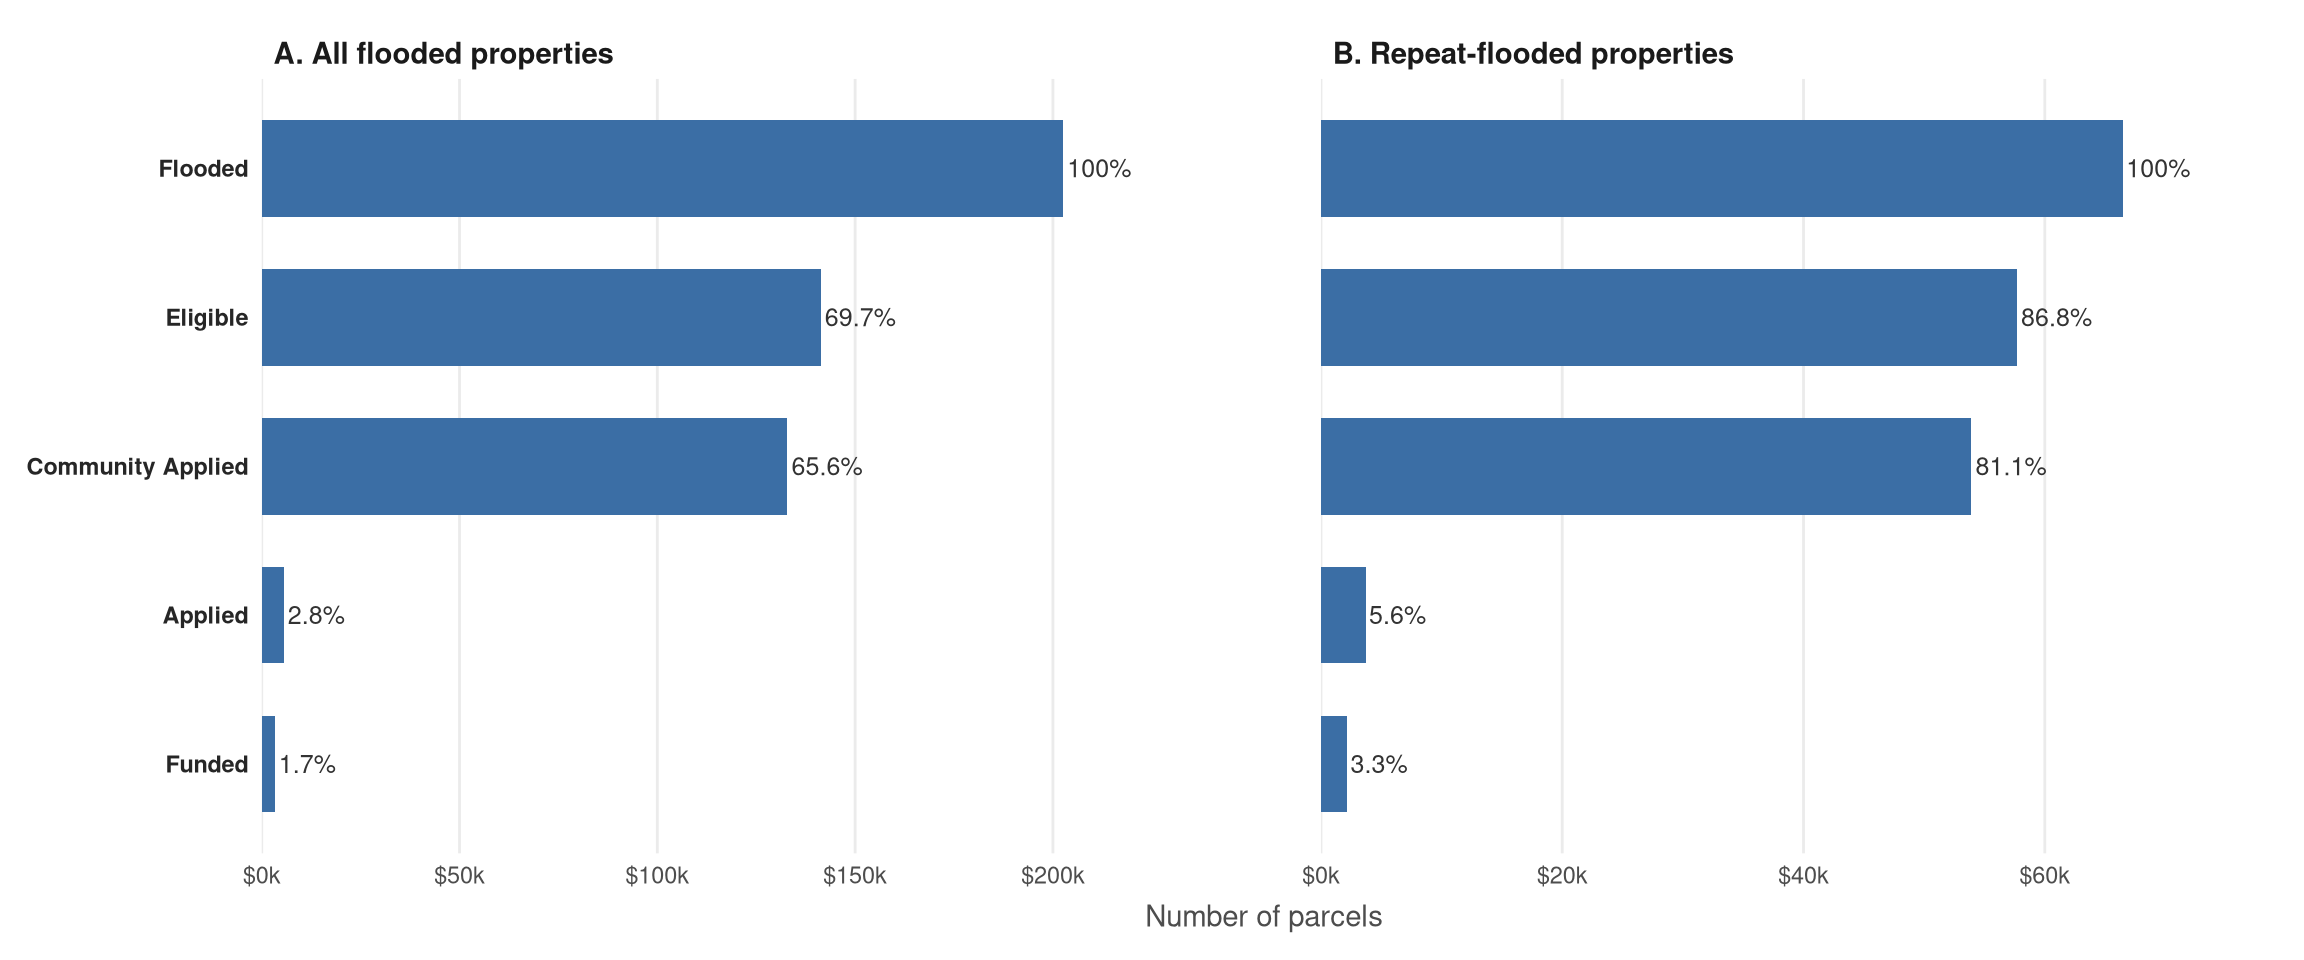

In [ ]:
stage_order_5 <- c("Flooded", "Eligible", "Community Applied",
                   "Applied", "Funded")

panel_labels_2 <- c(
  "All flood-exposed"    = "A. All flooded properties",
  "Repeat flood-exposed" = "B. Repeat-flooded properties"
)

fig2_data <- funnel |>
  mutate(
    stage = recode(as.character(stage),
                   "In a community" = "Community Applied"),
    stage = factor(stage, levels = stage_order_5),
    panel = factor(recode(group, !!!panel_labels_2),
                   levels = unname(panel_labels_2)),
    label_text = paste0(round(pct_of_flood * 100, 1), "%")
  )

fig2 <- ggplot(fig2_data, aes(x = n, y = stage)) +
  geom_col(fill = "#3b6ea5", width = 0.65) +
  geom_text(aes(label = label_text),
            hjust = -0.06, size = 3.3, colour = "grey20") +
  facet_wrap(~ panel, ncol = 2, scales = "free_x") +
  scale_x_continuous(
    expand = expansion(mult = c(0, 0.18)),
    labels = scales::label_dollar(scale = 1e-3, suffix = "k")
  ) +
  scale_y_discrete(limits = rev) +
  labs(
    #title = "Fig. 2  Flooded-to-funded pipeline",
    x = "Number of parcels",
    y = NULL
  ) +
  theme_minimal(base_size = 11) +
  theme(
    axis.text.y        = element_text(face = "bold", colour = "grey15"),
    axis.text.x        = element_text(colour = "grey30"),
    axis.title.x       = element_text(colour = "grey30", margin = margin(t = 6)),
    strip.text         = element_text(face = "bold", hjust = 0,
                                      colour = "grey10", size = 11),
    strip.background   = element_blank(),
    panel.grid.major.y = element_blank(),
    panel.grid.minor   = element_blank(),
    panel.spacing.x    = unit(1.5, "cm"),
    plot.title         = element_text(face = "bold"),
    plot.margin        = margin(10, 14, 10, 10)
  )

fig2

In [ ]:
dir.create(here::here("figures"), showWarnings = FALSE)
ggsave(here::here("figures", "fig2.png"),
       fig2, width = 7.48, height = 4, dpi = 300)

------------------------------------------------------------------------

## 7 Fig. 3 — property value distribution by pipeline stage

Each property’s value is converted to a **percentile** against the entire `fr_1_4` study-area sample. Histograms use 5% bins; the red vertical line marks the stage median. Four stages shown (Eligible dropped).

### 7.1 Build the percentile sample

In [ ]:
# Compute Panel B as percentile WITHIN block group instead of EIF cell.
# Filter to BGs with >= 5 parcels for meaningful within-neighborhood rank.
value_df <- pipeline |>
  filter(!is.na(value), value > 0, !is.na(bg_geoid)) |>
  mutate(
    pct_A = dplyr::percent_rank(value) * 100
  ) |>
  group_by(bg_geoid) |>
  mutate(
    bg_n  = dplyr::n(),
    pct_B = if_else(bg_n >= 5, dplyr::percent_rank(value) * 100, NA_real_)
  ) |>
  ungroup()

cat("sample parcels (fr_1_4 OR interp, w/ value + bg):",
    format(nrow(value_df), big.mark = ","), "\n")

sample parcels (fr_1_4 OR interp, w/ value + bg): 3,124,197 

distinct block groups: 4,469 

parcels with valid Panel B percentile (bg_n >= 5): 3,124,144 

### 7.2 Plot

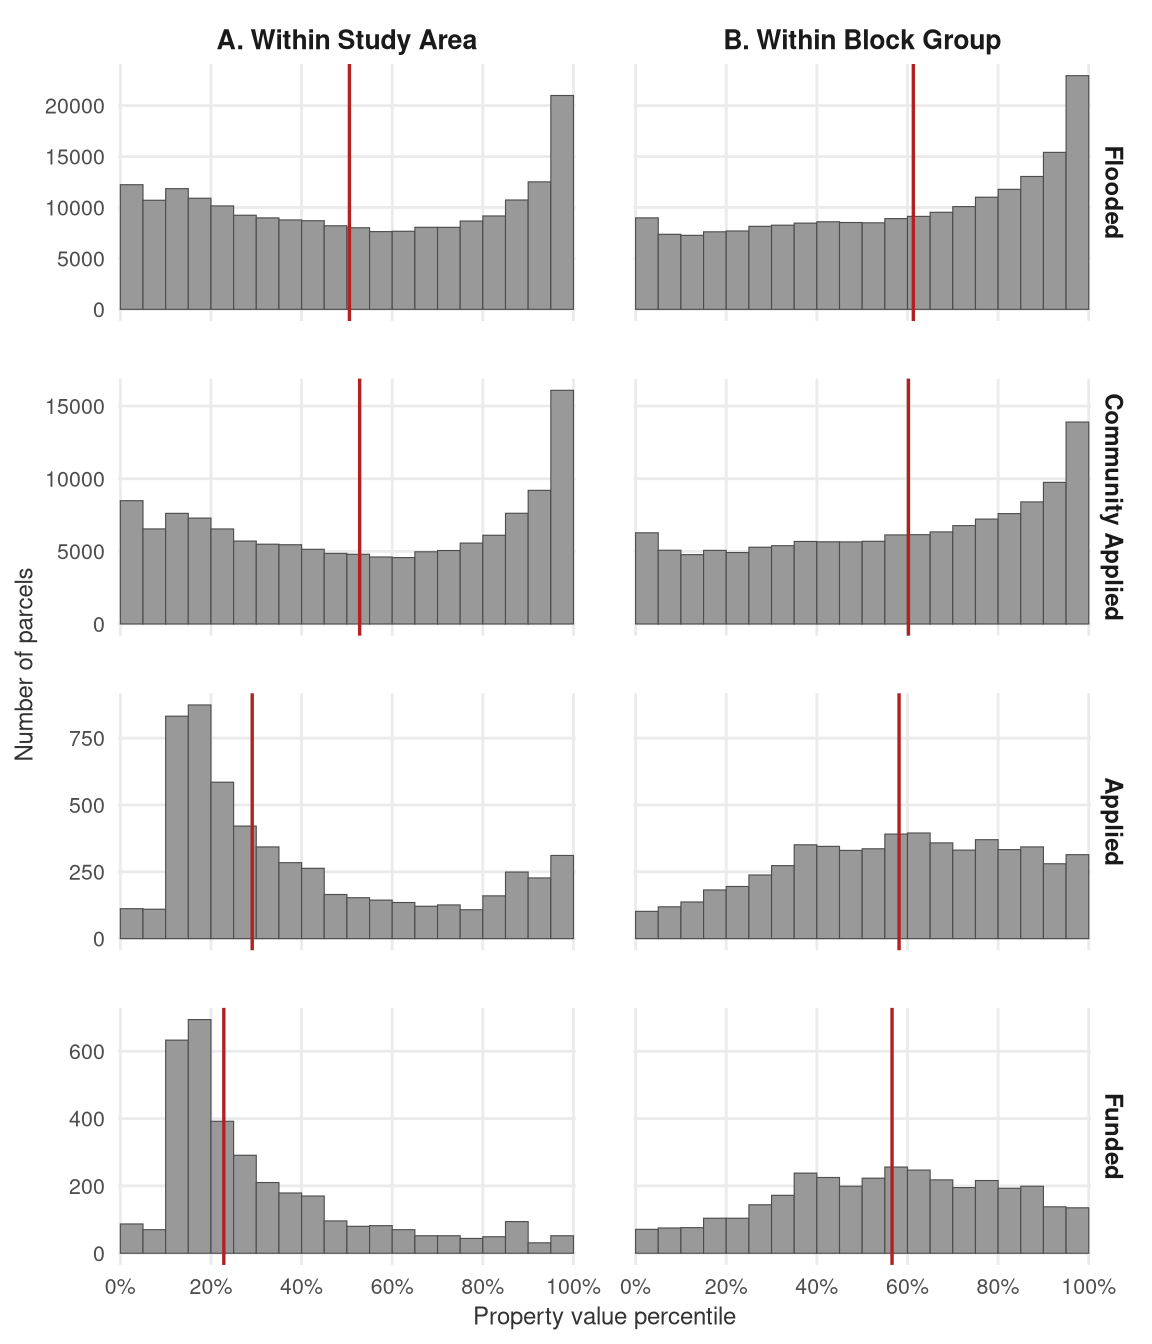

In [ ]:
stage_levels_4 <- c("Flooded", "Community Applied", "Applied", "Funded")

panel_labels_3 <- c(
  pct_A = "A. Within Study Area",
  pct_B = "B. Within Block Group"
)

fig3_hist_data <- bind_rows(
  value_df |> filter(reach1) |> mutate(stage = "Flooded"),
  value_df |> filter(reach3) |> mutate(stage = "Community Applied"),
  value_df |> filter(reach4) |> mutate(stage = "Applied"),
  value_df |> filter(reach5) |> mutate(stage = "Funded")
) |>
  select(stage, pct_A, pct_B) |>
  tidyr::pivot_longer(c(pct_A, pct_B),
                      names_to = "panel", values_to = "pct") |>
  filter(!is.na(pct)) |>
  mutate(
    stage = factor(stage, levels = stage_levels_4),
    panel = factor(recode(panel, !!!panel_labels_3),
                   levels = unname(panel_labels_3))
  )

fig3_medians <- fig3_hist_data |>
  group_by(panel, stage) |>
  summarise(median_pct = median(pct, na.rm = TRUE), .groups = "drop")

fig3 <- ggplot(fig3_hist_data, aes(x = pct)) +
  geom_histogram(binwidth = 5, boundary = 0,
                 fill = "grey60", colour = "grey30", linewidth = 0.2) +
  geom_vline(data = fig3_medians,
             aes(xintercept = median_pct),
             colour = "firebrick", linewidth = 0.6) +
  facet_grid(stage ~ panel, scales = "free_y") +
  scale_x_continuous(
    limits = c(0, 100),
    breaks = seq(0, 100, 20),
    labels = function(x) paste0(x, "%"),
    expand = c(0.005, 0)
  ) +
  labs(
    x = "Property value percentile",
    y = "Number of parcels"
  ) +
  theme_minimal(base_size = 11) +
  theme(
    strip.text.x       = element_text(face = "bold", size = 10),
    strip.text.y       = element_text(face = "bold", size = 9),
    strip.background   = element_blank(),
    strip.placement    = "outside",
    panel.grid.minor   = element_blank(),
    panel.spacing      = unit(1.5, "lines"),
    plot.title         = element_text(face = "bold"),
    axis.text          = element_text(size = 8, colour = "grey30"),
    axis.title         = element_text(size = 9, colour = "grey20")
  )

fig3

In [ ]:
readr::write_csv(fig3_medians,
                 here::here("figures", "fig3_medians.csv"))

dir.create(here::here("figures"), showWarnings = FALSE)
ggsave(file.path(here::here("figures"), "fig3.png"),
       fig3, width = 7.5, height = 9, dpi = 300)

------------------------------------------------------------------------

## 8 Fig. 4 — neighborhood racial composition by HMA stage

Two-panel figure following the draft’s Fig. 4 caption. **Panel A** is % Non-Hispanic White residents in the census block group containing each property (2013 ACS). **Panel B** is % Black residents in the same block group. A block group is at stage *k* if it contains ≥ 1 residential parcel that reached *k*. Block-group-level. Four stages shown (Eligible dropped); 5% bins; red line = median.

### 8.1 Build per-panel data

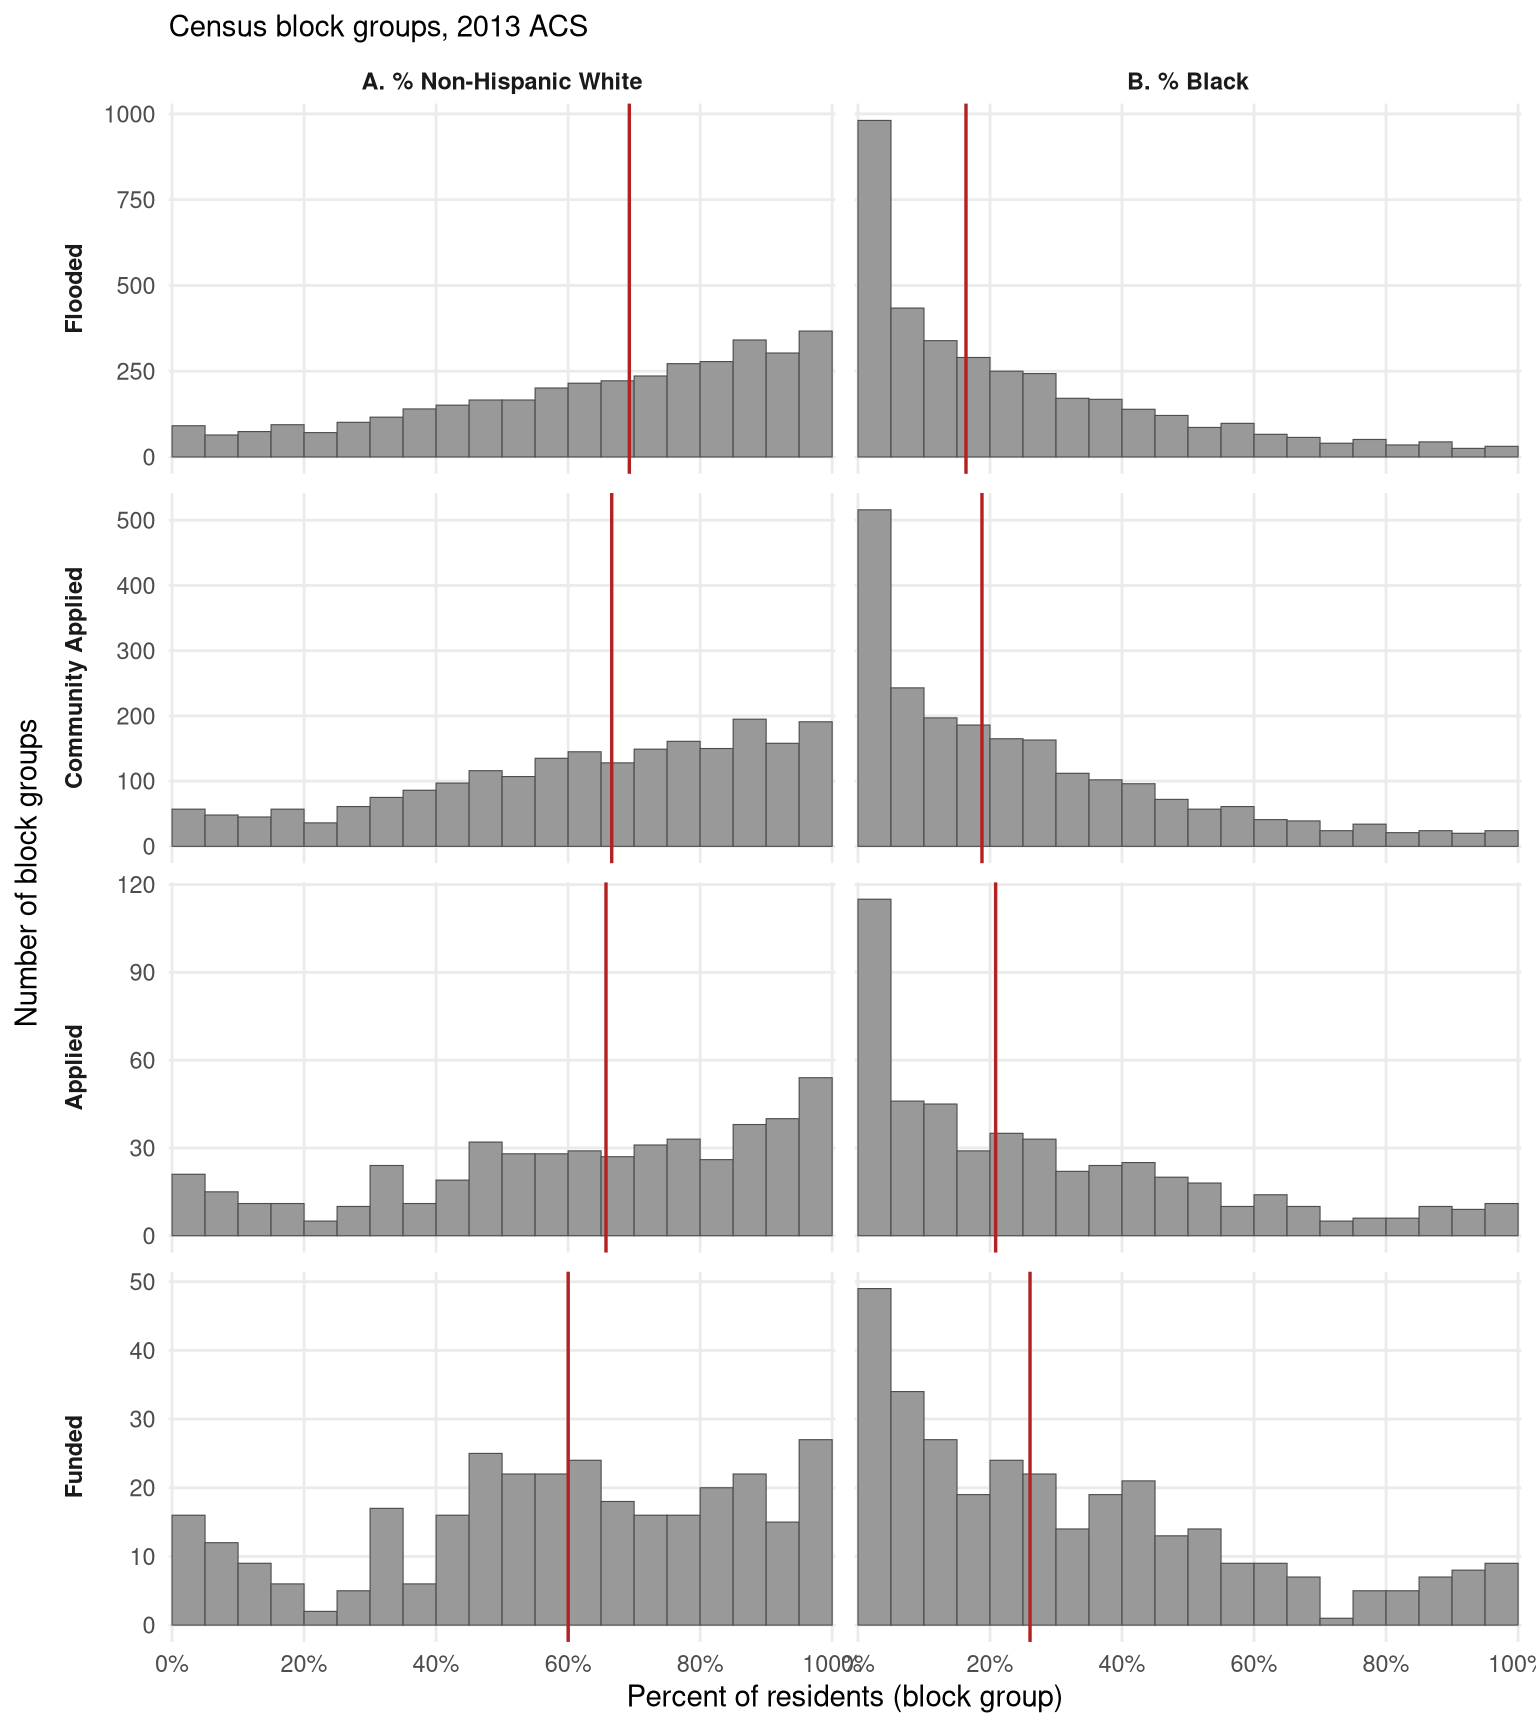

In [ ]:
# Per-block-group race shares — one row per BG, with stage flags.
# bg_pct_white_2013 / bg_pct_black_2013 are already on a 0-100 scale.
bgs_at_stage <- value_df |>
  filter(!is.na(bg_geoid)) |>
  group_by(bg_geoid) |>
  summarise(
    pct_white = dplyr::first(bg_pct_white_2013),
    pct_black = dplyr::first(bg_pct_black_2013),
    s1 = any(reach1, na.rm = TRUE),
    s3 = any(reach3, na.rm = TRUE),
    s4 = any(reach4, na.rm = TRUE),
    s5 = any(reach5, na.rm = TRUE),
    .groups = "drop"
  )

fig4_hist_data <- bgs_at_stage |>
  tidyr::pivot_longer(c(s1, s3, s4, s5),
                      names_to = "stage_key", values_to = "in_stage") |>
  filter(in_stage) |>
  mutate(stage = recode(stage_key,
    s1 = "Flooded", s3 = "Community Applied",
    s4 = "Applied", s5 = "Funded"
  )) |>
  select(stage, pct_white, pct_black) |>
  tidyr::pivot_longer(c(pct_white, pct_black),
                      names_to = "race", values_to = "pct") |>
  filter(!is.na(pct)) |>
  mutate(
    stage = factor(stage, levels = stage_levels_4),
    race  = factor(recode(race,
      pct_white = "A. % Non-Hispanic White",
      pct_black = "B. % Black"
    ), levels = c("A. % Non-Hispanic White", "B. % Black"))
  )

fig4_medians <- fig4_hist_data |>
  group_by(stage, race) |>
  summarise(median_pct = median(pct, na.rm = TRUE), .groups = "drop")

fig4 <- ggplot(fig4_hist_data, aes(x = pct)) +
  geom_histogram(binwidth = 5, boundary = 0,
                 fill = "grey60", colour = "grey30", linewidth = 0.2) +
  geom_vline(data = fig4_medians,
             aes(xintercept = median_pct),
             colour = "firebrick", linewidth = 0.6) +
  facet_grid(stage ~ race, scales = "free_y", switch = "y") +
  scale_x_continuous(limits = c(0, 100), breaks = seq(0, 100, 20),
                     labels = function(x) paste0(x, "%"),
                     expand = c(0.005, 0)) +
  labs(
    #title    = "Fig. 4  Neighborhood racial composition by HMA stage",
    subtitle = "Census block groups, 2013 ACS",
    x        = "Percent of residents (block group)",
    y        = "Number of block groups"
  ) +
  theme_minimal(base_size = 11) +
  theme(
    strip.text       = element_text(face = "bold"),
    strip.placement  = "outside",
    panel.grid.minor = element_blank(),
    panel.spacing    = unit(0.5, "lines"),
    plot.title       = element_text(face = "bold")
  )

fig4

### 8.2 Medians table

In [ ]:
fig4_medians |>
  mutate(
    n          = NA_integer_,   # counts live in fig4_hist_data if needed
    median_pct = round(median_pct, 1)
  ) |>
  select(race, stage, median_pct) |>
  arrange(race, stage) |>
  knitr::kable(col.names = c("Panel", "Stage", "Median pct"))

  Panel                     Stage                 Median pct
  ------------------------- ------------------- ------------
  A. % Non-Hispanic White   Flooded                     69.3
  A. % Non-Hispanic White   Community Applied           66.6
  A. % Non-Hispanic White   Applied                     65.7
  A. % Non-Hispanic White   Funded                      60.0
  B. % Black                Flooded                     16.4
  B. % Black                Community Applied           18.8
  B. % Black                Applied                     20.9
  B. % Black                Funded                      26.1


In [ ]:
dir.create(here::here("figures"), showWarnings = FALSE)
ggsave(here::here("figures", "fig4.png"),
       fig4, width = 8, height = 9, dpi = 300)
write_csv(fig4_medians, here::here("figures", "fig4_medians.csv"))

## 9 Fig. 5 — supplementary block-group economic distributions

Block-group medians for household income and home value across the flooded-to-funded pipeline. Block-group-level (one observation per BG that contains a residential parcel reaching the stage). Same 4-stage structure as Fig. 4; same histogram style. Two separate panels because income and home value live on different dollar scales.

### 9.1 Build per-panel data

In [ ]:
# Per-block-group economic medians, with stage flags. Same aggregation as Fig 4.
bgs_econ_at_stage <- value_df |>
  filter(!is.na(bg_geoid)) |>
  group_by(bg_geoid) |>
  summarise(
    income = dplyr::first(bg_median_income_2013),
    hvalue = dplyr::first(bg_median_home_value_2013),
    s1 = any(reach1, na.rm = TRUE),
    s3 = any(reach3, na.rm = TRUE),
    s4 = any(reach4, na.rm = TRUE),
    s5 = any(reach5, na.rm = TRUE),
    .groups = "drop"
  )

fig5_long <- bgs_econ_at_stage |>
  tidyr::pivot_longer(c(s1, s3, s4, s5),
                      names_to = "stage_key", values_to = "in_stage") |>
  filter(in_stage) |>
  mutate(stage = recode(stage_key,
    s1 = "Flooded", s3 = "Community Applied",
    s4 = "Applied", s5 = "Funded"
  )) |>
  mutate(stage = factor(stage, levels = stage_levels_4))

fig5_income <- fig5_long |>
  select(stage, val = income) |>
  filter(!is.na(val))
fig5_hvalue <- fig5_long |>
  select(stage, val = hvalue) |>
  filter(!is.na(val))

fig5_medians <- bind_rows(
  fig5_income |> group_by(stage) |>
    summarise(median_val = median(val, na.rm = TRUE), .groups = "drop") |>
    mutate(metric = "income"),
  fig5_hvalue |> group_by(stage) |>
    summarise(median_val = median(val, na.rm = TRUE), .groups = "drop") |>
    mutate(metric = "hvalue")
)

knitr::kable(
  fig5_medians |>
    mutate(median_val = round(median_val, 0)) |>
    arrange(metric, stage),
  caption = "Fig 5 supplementary medians by stage"
)

  stage                 median_val metric
  ------------------- ------------ --------
  Flooded                   129500 hvalue
  Community Applied         124850 hvalue
  Applied                   124350 hvalue
  Funded                    109050 hvalue
  Flooded                    43280 income
  Community Applied          42955 income
  Applied                    42282 income
  Funded                     40694 income

  : Fig 5 supplementary medians by stage


### 9.2 Panel A — household income

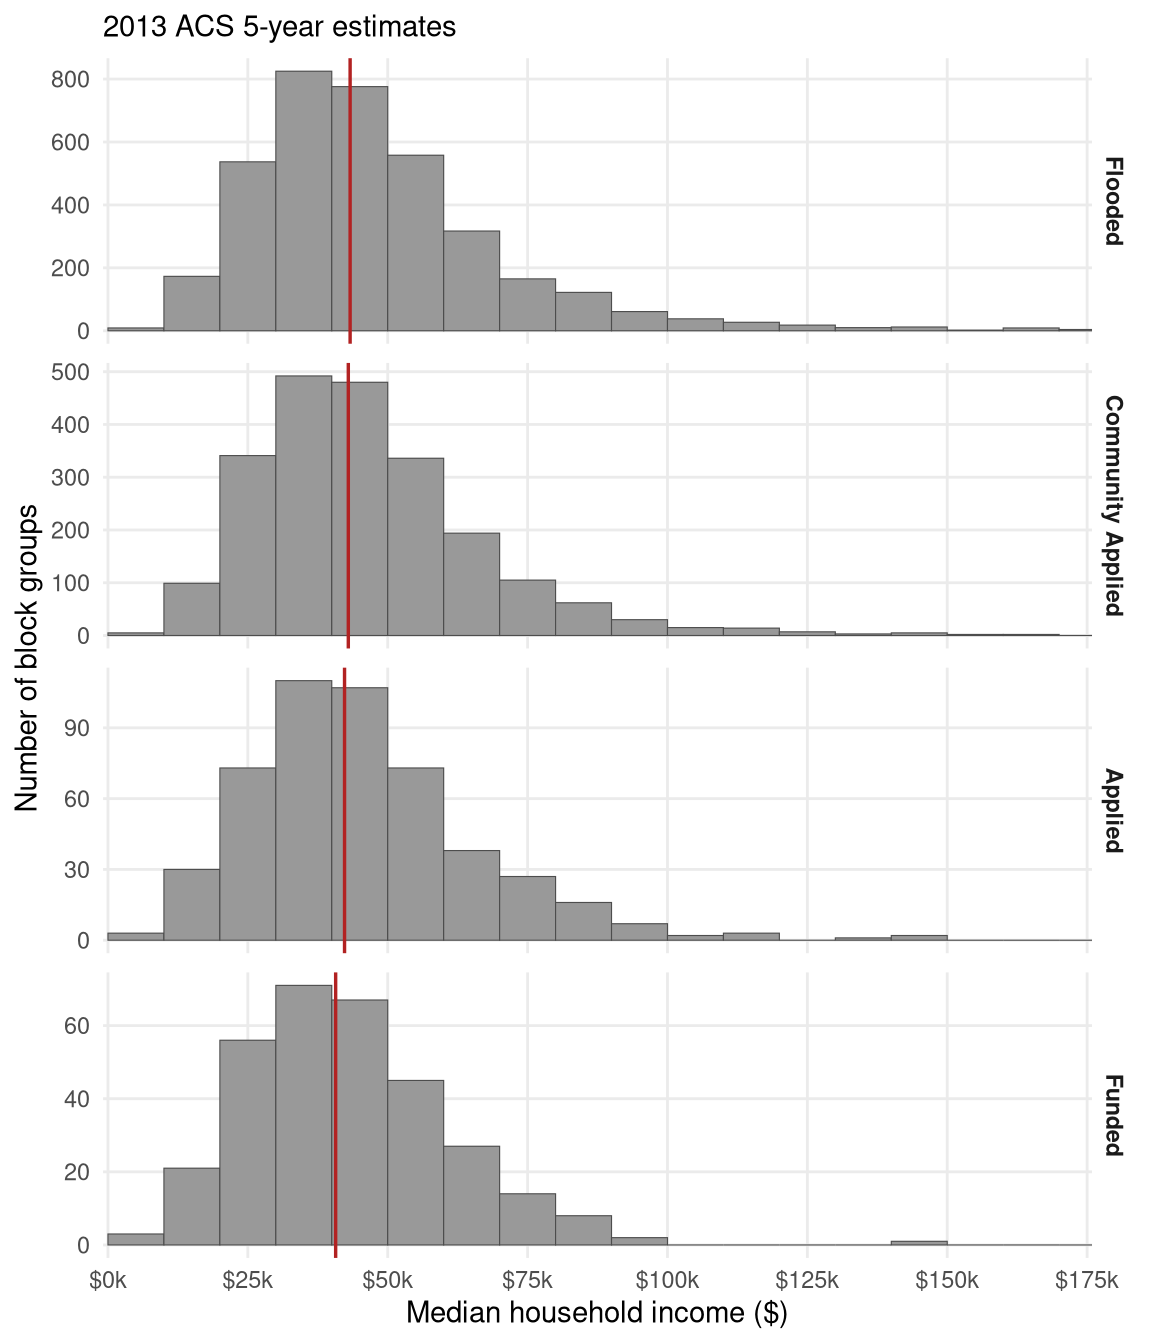

In [ ]:
inc_medians <- fig5_medians |> filter(metric == "income")

fig5a <- ggplot(fig5_income, aes(x = val)) +
  geom_histogram(binwidth = 10000, boundary = 0,
                 fill = "grey60", colour = "grey30", linewidth = 0.2) +
  geom_vline(data = inc_medians,
             aes(xintercept = median_val),
             colour = "firebrick", linewidth = 0.6) +
  facet_wrap(~ stage, ncol = 1, scales = "free_y", strip.position = "right") +
  coord_cartesian(xlim = c(0, 175000)) +
  scale_x_continuous(
    breaks = seq(0, 175000, 25000),
    labels = scales::label_dollar(scale = 1e-3, suffix = "k"),
    expand = c(0.005, 0)
  ) +
  labs(
    #title    = "Fig. 5a  Block-group median household income by HMA stage",
    subtitle = "2013 ACS 5-year estimates",
    x        = "Median household income ($)",
    y        = "Number of block groups"
  ) +
  theme_minimal(base_size = 11) +
  theme(
    strip.text.y     = element_text(face = "bold"),
    panel.grid.minor = element_blank(),
    panel.spacing.y  = unit(0.5, "lines"),
    plot.title       = element_text(face = "bold")
  )

fig5a

### 9.3 Panel B — home value

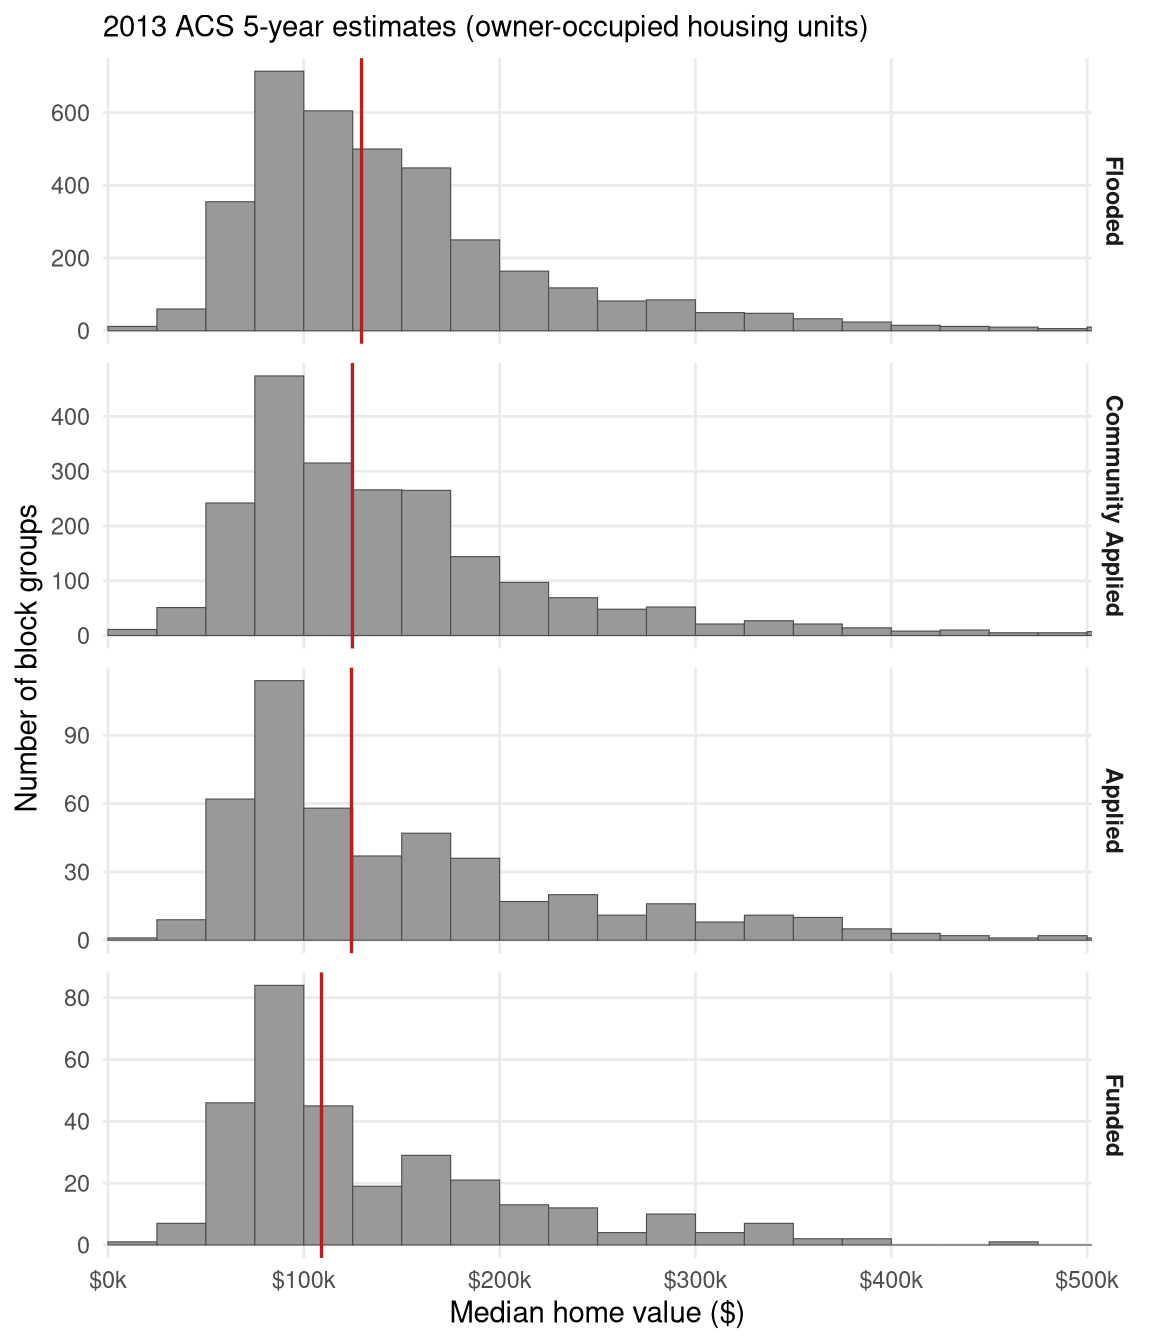

In [ ]:
hv_medians <- fig5_medians |> filter(metric == "hvalue")

fig5b <- ggplot(fig5_hvalue, aes(x = val)) +
  geom_histogram(binwidth = 25000, boundary = 0,
                 fill = "grey60", colour = "grey30", linewidth = 0.2) +
  geom_vline(data = hv_medians,
             aes(xintercept = median_val),
             colour = "firebrick", linewidth = 0.6) +
  facet_wrap(~ stage, ncol = 1, scales = "free_y", strip.position = "right") +
  coord_cartesian(xlim = c(0, 500000)) +
  scale_x_continuous(
    breaks = seq(0, 500000, 100000),
    labels = scales::label_dollar(scale = 1e-3, suffix = "k"),
    expand = c(0.005, 0)
  ) +
  labs(
    #title    = "Fig. 5b  Block-group median home value by HMA stage",
    subtitle = "2013 ACS 5-year estimates (owner-occupied housing units)",
    x        = "Median home value ($)",
    y        = "Number of block groups"
  ) +
  theme_minimal(base_size = 11) +
  theme(
    strip.text.y     = element_text(face = "bold"),
    panel.grid.minor = element_blank(),
    panel.spacing.y  = unit(0.5, "lines"),
    plot.title       = element_text(face = "bold")
  )

fig5b

### 9.4 Save

In [ ]:
dir.create(here::here("figures"), showWarnings = FALSE)
ggsave(here::here("figures", "fig5a_income.png"),
       fig5a, width = 6, height = 7, dpi = 300)
ggsave(here::here("figures", "fig5b_home_value.png"),
       fig5b, width = 6, height = 7, dpi = 300)
write_csv(fig5_medians, here::here("figures", "fig5_medians.csv"))

In [ ]:
# Pre-compute everything the manuscript prose references inline.
# Saved as a single small RDS so index.qmd can read it without touching
# parcels_master.gpkg — making the manuscript renderable from any machine.

index_inputs <- list(
  # Sample sizes
  n_sample        = sum(parcels$res_flag == 1L | parcels$interpolate == 1L,
                        na.rm = TRUE),
  n_counties      = length(unique(parcels$county)),
  n_bg            = length(unique(parcels$bg_geoid[!is.na(parcels$bg_geoid)])),

  # Pipeline funnel — both groups in long format
  funnel = funnel,

  # Figure medians
  fig3_medians = fig3_medians,
  fig4_medians = fig4_medians,
  fig5_medians = fig5_medians
)

# Also pull the CoreLogic-vs-ACS agreement summary from 07b's output, if it exists.
# Wrapped in tryCatch so Step 8 still runs cleanly if the file isn't there yet.
acs_cl_summary <- tryCatch({
  cmp <- readr::read_csv(file.path(out_dir, "acs_corelogic_value_comparison.csv"),
                         show_col_types = FALSE)
  list(
    n_bgs            = nrow(cmp),
    spearman_rho     = cor(cmp$cl_median_tvc, cmp$bg_median_home_value_2013,
                           method = "spearman"),
    median_ratio     = median(cmp$cl_median_tvc / cmp$bg_median_home_value_2013,
                              na.rm = TRUE)
  )
}, error = function(e) NULL)

index_inputs$acs_cl_summary <- acs_cl_summary

saveRDS(index_inputs, here::here("figures", "index_inputs.rds"))
cat("Wrote index_inputs.rds with", length(index_inputs), "elements\n")

Wrote index_inputs.rds with 8 elements